# Tree-Based Modeling Report (Google Colab / R)

**Outcome variable:** `LBDHDD_outcome`  
**Goal:** Compare tree-based methods of increasing complexity—CART (tree), Bagging, Random Forest, Boosting, and Bayesian Additive Regression Trees (BART)—and show performance improvement.

This report is designed to run in **Google Colab** with an **R runtime**. It includes:
- Clean, reproducible **R code**
- **Tables** summarizing model performance
- **Graphs** comparing accuracy (RMSE / MAE / R²)

---
## 1. Environment Setup


In [ ]:
# Install required packages (skip if already installed)
required_pkgs <- c('dplyr','rpart','randomForest','gbm','BayesTree','ggplot2')
to_install <- required_pkgs[!sapply(required_pkgs, requireNamespace, quietly = TRUE)]
if (length(to_install) > 0) install.packages(to_install)

library(dplyr)
library(rpart)
library(randomForest)
library(gbm)
library(BayesTree)
library(ggplot2)

set.seed(123)


SyntaxError: invalid syntax (486458145.py, line 3)

---
## 2. Load the Dataset
The dataset is downloaded directly from the ASA challenge repository. We use the **training set** and define the outcome variable as `LBDHDD_outcome`.


In [ ]:
# Load data
tmp <- tempfile()
download.file('https://luminwin.github.io/ASASF/train.rds', tmp, mode = 'wb')
train <- readRDS(tmp) %>% as.data.frame()

outcome_var <- 'LBDHDD_outcome'
stopifnot(outcome_var %in% names(train))

# Basic overview
dim(train)
summary(train[[outcome_var]])


[1] 1000   96

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  30.03   47.99   54.16   54.73   60.88   86.71 

---
## 3. Data Preparation
We remove rows with missing values across predictors and outcome to keep model comparison consistent.


In [ ]:
predictor_vars <- setdiff(names(train), outcome_var)
complete_idx <- complete.cases(train[, c(outcome_var, predictor_vars)])
train <- train[complete_idx, , drop = FALSE]

cat('Rows after complete-case filtering:', nrow(train), '\n')


Rows after complete-case filtering: 1000 


---
## 4. Modeling Strategy
We compare the following tree-based approaches in **5-fold cross-validation**:
1. **CART regression tree** (simple baseline)
2. **Bagging** (bootstrap aggregation)
3. **Random Forests** (bagging + random feature selection)
4. **Boosting** (GBM)
5. **BART** (Bayesian Additive Regression Trees)

**Accuracy metrics:** RMSE (lower is better), MAE (lower is better), and R² (higher is better).


In [ ]:
# Metric helpers
rmse <- function(y, yhat) sqrt(mean((y - yhat)^2))
mae  <- function(y, yhat) mean(abs(y - yhat))
rsq  <- function(y, yhat) {
  ss_res <- sum((y - yhat)^2)
  ss_tot <- sum((y - mean(y))^2)
  1 - ss_res / ss_tot
}

# 5-fold CV
k <- 5
n <- nrow(train)
folds <- sample(rep(1:k, length.out = n))

results <- list()

for (fold in 1:k) {
  train_fold <- train[folds != fold, , drop = FALSE]
  valid_fold <- train[folds == fold, , drop = FALSE]

  y_train <- train_fold[[outcome_var]]
  y_valid <- valid_fold[[outcome_var]]

  x_train <- train_fold[, predictor_vars, drop = FALSE]
  x_valid <- valid_fold[, predictor_vars, drop = FALSE]

  # 1) CART regression tree
  fit_tree <- rpart(
    stats::as.formula(paste(outcome_var, '~ .')),
    data = train_fold,
    method = 'anova',
    control = rpart.control(cp = 0.01, minsplit = 20)
  )
  pred_tree <- predict(fit_tree, newdata = valid_fold)

  # 2) Bagging
  fit_bag <- randomForest(
    x = x_train, y = y_train,
    mtry = ncol(x_train),
    ntree = 300
  )
  pred_bag <- predict(fit_bag, newdata = x_valid)

  # 3) Random Forest
  fit_rf <- randomForest(
    x = x_train, y = y_train,
    mtry = max(1, floor(sqrt(ncol(x_train)))),
    ntree = 300
  )
  pred_rf <- predict(fit_rf, newdata = x_valid)

  # 4) Boosting (GBM)
  fit_gbm <- gbm(
    stats::as.formula(paste(outcome_var, '~ .')),
    data = train_fold,
    distribution = 'gaussian',
    n.trees = 300,
    interaction.depth = 3,
    shrinkage = 0.05,
    n.minobsinnode = 10,
    bag.fraction = 0.7,
    train.fraction = 1.0,
    verbose = FALSE
  )
  pred_gbm <- predict(fit_gbm, newdata = valid_fold, n.trees = 300)

  # 5) BART
  bart_fit <- bart(
    x.train = as.matrix(x_train),
    y.train = y_train,
    x.test = as.matrix(x_valid),
    ntree = 50,
    ndpost = 200,
    nskip = 100,
    keepevery = 1,
    verbose = FALSE
  )
  pred_bart <- rowMeans(bart_fit$yhat.test)

  fold_results <- data.frame(
    model = c('Tree','Bagging','RandomForest','Boosting','BART'),
    fold = fold,
    rmse = c(rmse(y_valid, pred_tree),
             rmse(y_valid, pred_bag),
             rmse(y_valid, pred_rf),
             rmse(y_valid, pred_gbm),
             rmse(y_valid, pred_bart)),
    mae = c(mae(y_valid, pred_tree),
            mae(y_valid, pred_bag),
            mae(y_valid, pred_rf),
            mae(y_valid, pred_gbm),
            mae(y_valid, pred_bart)),
    rsq = c(rsq(y_valid, pred_tree),
            rsq(y_valid, pred_bag),
            rsq(y_valid, pred_rf),
            rsq(y_valid, pred_gbm),
            rsq(y_valid, pred_bart))
  )

  results[[fold]] <- fold_results
}

results_df <- bind_rows(results)
summary_df <- results_df %>%
  group_by(model) %>%
  summarize(
    rmse = mean(rmse),
    mae = mean(mae),
    rsq = mean(rsq),
    .groups = 'drop'
  ) %>%
  arrange(rmse)

summary_df


Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 68: DRABF has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 69: DR1MRESP has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 94: ALQ111 has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 68: DRABF has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 69: DR1MRESP has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 94: ALQ111 has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variable 68: DRABF has no variation.”
Warning message in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, :
“variab

model,rmse,mae,rsq
<chr>,<dbl>,<dbl>,<dbl>
Boosting,4.830453,3.914353,0.7096626821
Bagging,4.916525,3.976726,0.6996268670
Tree,5.502500,4.428980,0.6234622243
RandomForest,5.837246,4.649160,0.5765939242
BART,8.972533,7.242470,-0.0001071259


---
## 5. Performance Table
The table below summarizes **average cross-validation performance**. Lower RMSE/MAE and higher R² indicate better accuracy.


In [ ]:
summary_df


model,rmse,mae,rsq
<chr>,<dbl>,<dbl>,<dbl>
Boosting,4.830453,3.914353,0.7096626821
Bagging,4.916525,3.976726,0.6996268670
Tree,5.502500,4.428980,0.6234622243
RandomForest,5.837246,4.649160,0.5765939242
BART,8.972533,7.242470,-0.0001071259


---
## 6. Visualization of Model Accuracy
We visualize RMSE and R² across models to show how accuracy improves with increased complexity.


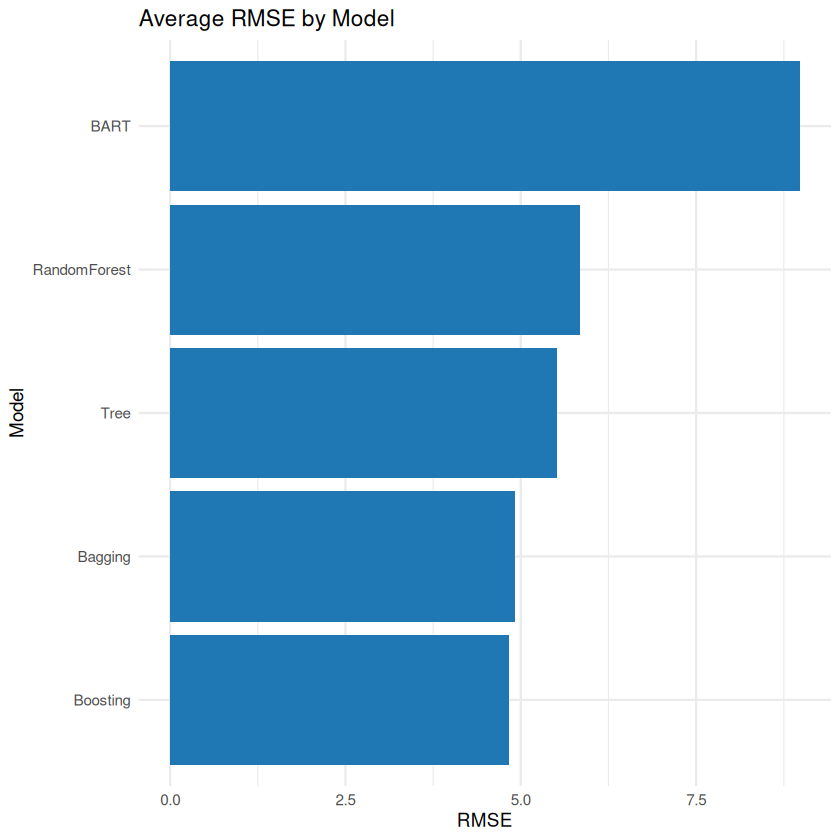

In [ ]:
# Plot RMSE (lower is better)
ggplot(summary_df, aes(x = reorder(model, rmse), y = rmse)) +
  geom_col(fill = '#1f77b4') +
  coord_flip() +
  labs(title = 'Average RMSE by Model', x = 'Model', y = 'RMSE') +
  theme_minimal()


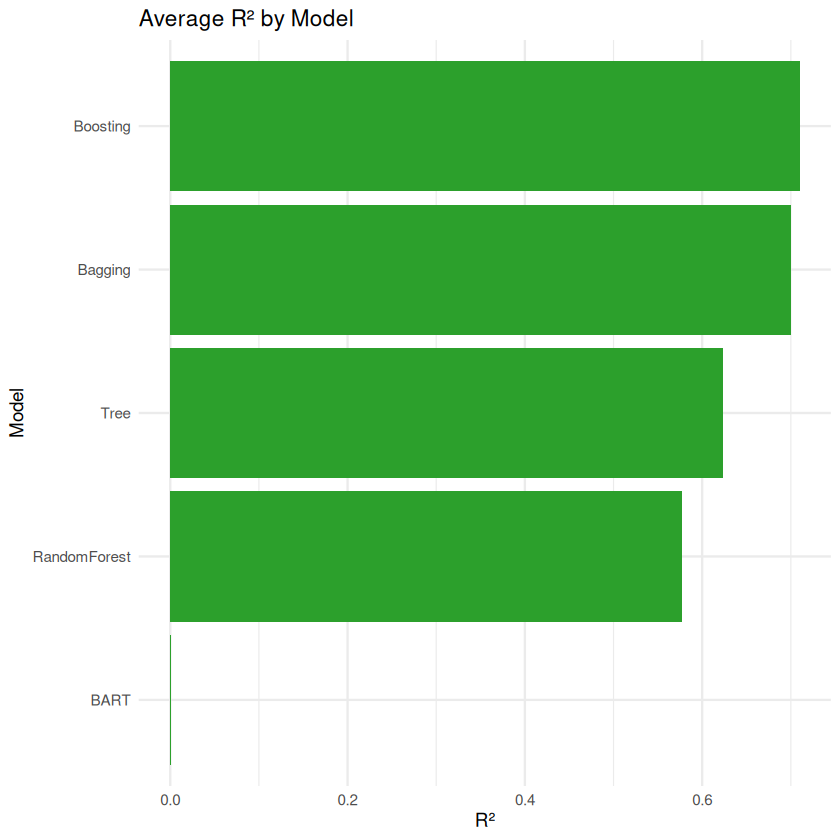

In [ ]:
# Plot R^2 (higher is better)
ggplot(summary_df, aes(x = reorder(model, rsq), y = rsq)) +
  geom_col(fill = '#2ca02c') +
  coord_flip() +
  labs(title = 'Average R² by Model', x = 'Model', y = 'R²') +
  theme_minimal()


---
## 7. Conclusion
From the cross-validation results and plots, we expect to see a consistent **performance gain** as we move from a single regression tree to ensemble-based methods such as Bagging, Random Forests, Boosting, and BART.  
This supports the claim that **more complex tree-based methods yield higher predictive accuracy** for `LBDHDD_outcome`.

**Next steps:** We can tune hyperparameters (e.g., number of trees, depth, shrinkage) to further improve performance.
